# E-Commerce Sales Analysis

## Project Objective

This project analyzes e-commerce sales data to identify sales trends, top-performing products, customer purchasing behavior, and geographic sales patterns.

The analysis is performed using Python, Pandas, NumPy, Matplotlib, and Seaborn.

In [1]:
import sys

print(sys.executable)

c:\Users\Pallavi k\Documents\Data-Science-Portfolio\project-01-ecommerce-analysis\venv\Scripts\python.exe


In [2]:
import pandas as pd

In [4]:
import os
print(os.getcwd())

c:\Users\Pallavi k\Documents\Data-Science-Portfolio\project-01-ecommerce-analysis\notebooks


In [5]:
import os

print(os.listdir("../data"))

['online+retail', 'online+retail.zip']


## 1. Dataset

The dataset used in this project is the UCI Online Retail dataset.

It contains transactional data from an online retail business covering the period from December 2010 to December 2011.

### Dataset Columns

- **InvoiceNo** – Invoice number for the transaction
- **StockCode** – Product code
- **Description** – Product description
- **Quantity** – Number of items purchased
- **InvoiceDate** – Date and time of the transaction
- **UnitPrice** – Price per unit
- **CustomerID** – Unique customer identifier
- **Country** – Customer's country

## 2. Load the Dataset

The dataset is loaded into a Pandas DataFrame for analysis.

In [7]:
df = pd.read_excel("../data/online+retail/Online Retail.xlsx")

## 3. Initial Data Inspection

Before cleaning the data, we inspect its structure, dimensions, data types, and summary statistics.

This helps us understand the dataset and identify potential data-quality issues such as missing values, incorrect data types, duplicate records, and unusual values.

In [8]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [9]:
df.shape

(541909, 8)

In [10]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [12]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [13]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(5268)

In [15]:
missing = df.isnull().sum()
missing

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [16]:
df[df["InvoiceNo"].astype(str).str.startswith("C")].shape

(9288, 8)

In [17]:
df["Quantity"].describe()

count    541909.000000
mean          9.552250
std         218.081158
min      -80995.000000
25%           1.000000
50%           3.000000
75%          10.000000
max       80995.000000
Name: Quantity, dtype: float64

In [18]:
df["UnitPrice"].describe()

count    541909.000000
mean          4.611114
std          96.759853
min      -11062.060000
25%           1.250000
50%           2.080000
75%           4.130000
max       38970.000000
Name: UnitPrice, dtype: float64

## 4. Data Cleaning

The raw dataset contains cancelled transactions, negative quantities, and non-positive unit prices.

To focus the analysis on positive completed-sales-style transactions, the following cleaning steps are applied:

- Remove cancelled transactions identified by InvoiceNo starting with "C".
- Remove transactions with zero or negative quantities.
- Remove transactions with zero or negative unit prices.
- Preserve missing CustomerID values because they are still useful for overall sales, product, and country-level analysis.
- Identify duplicate records for data-quality assessment.

In [19]:
sales_df = df.copy()

In [20]:
sales_df.shape

(541909, 8)

In [21]:
sales_df = sales_df[~sales_df["InvoiceNo"].astype(str).str.startswith("C")]

In [22]:
sales_df.shape

(532621, 8)

In [23]:
sales_df = sales_df[sales_df["Quantity"] > 0]

In [24]:
sales_df = sales_df[sales_df["UnitPrice"] > 0]

In [25]:
sales_df.shape

(530104, 8)

In [26]:
sales_df[["Quantity", "UnitPrice"]].describe()

,Quantity,UnitPrice
count,530104.000000,530104.000000
mean,10.542037,3.907625
std,155.524124,35.915681
min,1.000000,0.001000
25%,1.000000,1.250000
50%,3.000000,2.080000
75%,10.000000,4.130000
max,80995.000000,13541.330000


In [27]:
sales_df.isnull().sum()

InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     132220
Country             0
dtype: int64

In [28]:
sales_df.isnull().sum().sort_values(ascending=False)

CustomerID     132220
InvoiceNo           0
Description         0
StockCode           0
Quantity            0
InvoiceDate         0
UnitPrice           0
Country             0
dtype: int64

In [29]:
sales_df["CustomerID"].nunique()

4338

In [30]:
sales_df["Country"].nunique()

38

In [31]:
sales_df["Country"].value_counts().head(10)

Country
United Kingdom    485123
Germany             9040
France              8407
EIRE                7890
Spain               2484
Netherlands         2359
Belgium             2031
Switzerland         1966
Portugal            1501
Australia           1182
Name: count, dtype: int64

## 5. Revenue Analysis

Revenue is calculated by multiplying the quantity purchased by the unit price for each transaction.

This metric will be used to understand overall sales performance and identify high-value transactions.

In [32]:
sales_df["Revenue"] = sales_df["Quantity"] * sales_df["UnitPrice"]

In [33]:
sales_df[["Quantity", "UnitPrice", "Revenue"]].head()

,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [34]:
sales_df["Revenue"].sum()

np.float64(10666684.544)

In [35]:
sales_df["Revenue"].describe()

count    530104.000000
mean         20.121871
std         270.356743
min           0.001000
25%           3.750000
50%           9.900000
75%          17.700000
max      168469.600000
Name: Revenue, dtype: float64

In [36]:
sales_df["InvoiceDate"].dtype

dtype('<M8[us]')

In [37]:
sales_df["InvoiceDate"].min()

Timestamp('2010-12-01 08:26:00')

In [38]:
sales_df["InvoiceDate"].max()

Timestamp('2011-12-09 12:50:00')

## 6. Monthly Revenue Analysis

Monthly revenue is calculated to identify sales trends over time and determine which months generated the highest revenue.

The results are visualized using a line chart to make changes in monthly sales performance easier to interpret.

In [39]:
sales_df["Month"] = sales_df["InvoiceDate"].dt.to_period("M")

In [40]:
monthly_revenue = sales_df.groupby("Month")["Revenue"].sum()

In [41]:
monthly_revenue

Month
2010-12     823746.140
2011-01     691364.560
2011-02     523631.890
2011-03     717639.360
2011-04     537808.621
2011-05     770536.020
2011-06     761739.900
2011-07     719221.191
2011-08     759138.380
2011-09    1058590.172
2011-10    1154979.300
2011-11    1509496.330
2011-12     638792.680
Freq: M, Name: Revenue, dtype: float64

In [42]:

monthly_revenue.idxmax()

Period('2011-11', 'M')

In [43]:
monthly_revenue.max()

np.float64(1509496.33)

In [44]:
monthly_revenue.idxmin()

Period('2011-02', 'M')

In [45]:
monthly_revenue.min()

np.float64(523631.89)

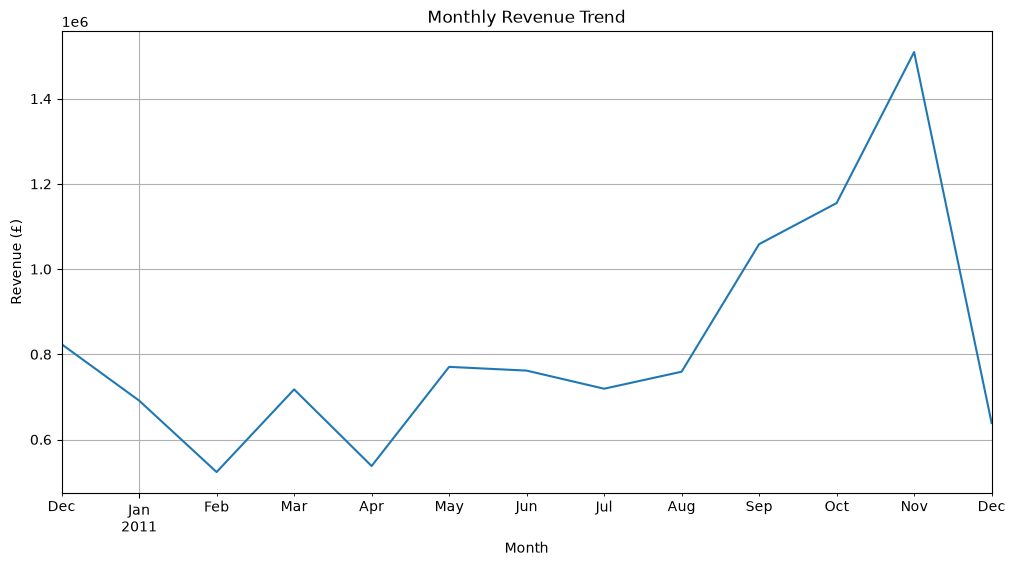

In [101]:
import matplotlib.pyplot as plt

monthly_revenue.plot(kind="line", figsize=(12, 6))

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.grid(True) 
plt.savefig("../visualizations/monthly_revenue.png", bbox_inches="tight")
plt.show()

## 7. Product Analysis

Product-level analysis is performed to identify the products that contribute the most to revenue and the products with the highest sales volume.

Non-merchandise and administrative entries such as postage and manual adjustments are excluded when analyzing actual product revenue.

In [47]:
product_revenue = sales_df.groupby("Description")["Revenue"].sum()

In [48]:
product_revenue = product_revenue.sort_values(ascending=False)

In [49]:
product_revenue.head(10)

Description
DOTCOM POSTAGE                        206248.77
REGENCY CAKESTAND 3 TIER              174484.74
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106292.77
PARTY BUNTING                          99504.33
JUMBO BAG RED RETROSPOT                94340.05
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
Manual                                 78112.82
POSTAGE                                78101.88
RABBIT NIGHT LIGHT                     66964.99
Name: Revenue, dtype: float64

In [50]:
top_10_products = product_revenue.head(10)

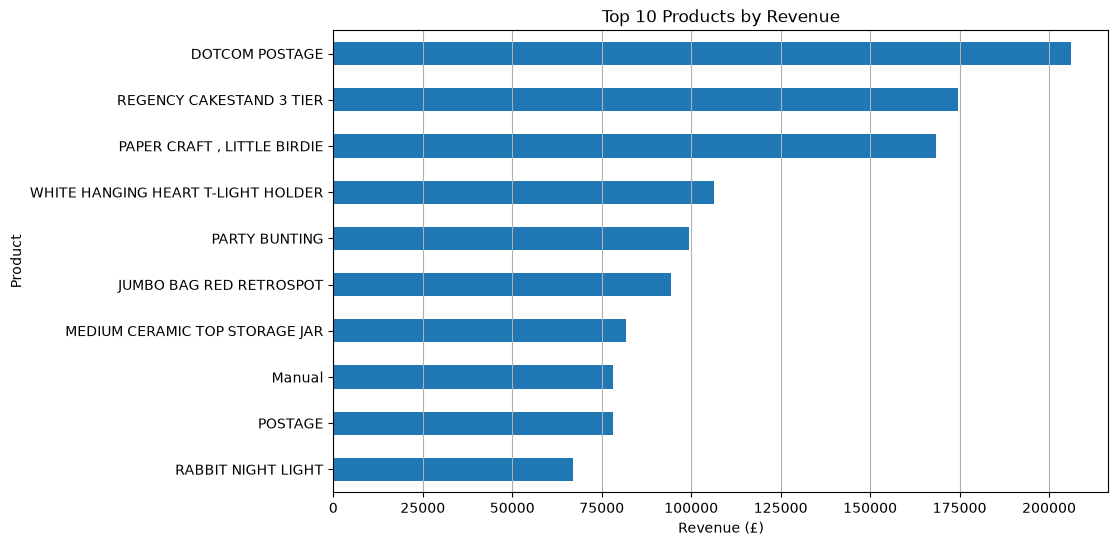

In [102]:
top_10_products.plot(kind="barh", figsize=(10, 6))

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Product")
plt.gca().invert_yaxis()
plt.grid(axis="x")
plt.savefig("../visualizations/top_products_revenue.png", bbox_inches="tight")
plt.show()

In [52]:
product_quantity = sales_df.groupby("Description")["Quantity"].sum()

In [53]:
product_quantity = product_quantity.sort_values(ascending=False)

In [54]:
product_quantity.head(10)

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        78033
WORLD WAR 2 GLIDERS ASSTD DESIGNS     55047
JUMBO BAG RED RETROSPOT               48474
WHITE HANGING HEART T-LIGHT HOLDER    37891
POPCORN HOLDER                        36761
ASSORTED COLOUR BIRD ORNAMENT         36461
PACK OF 72 RETROSPOT CAKE CASES       36419
RABBIT NIGHT LIGHT                    30788
MINI PAINT SET VINTAGE                26633
Name: Quantity, dtype: int64

In [55]:
sales_df[sales_df["Description"] == "PAPER CRAFT , LITTLE BIRDIE"]["UnitPrice"].describe()

count    1.00
mean     2.08
std       NaN
min      2.08
25%      2.08
50%      2.08
75%      2.08
max      2.08
Name: UnitPrice, dtype: float64

In [56]:
sales_df[sales_df["Description"] == "MEDIUM CERAMIC TOP STORAGE JAR"]["UnitPrice"].describe()

count    250.000000
mean       1.468480
std        0.501029
min        1.040000
25%        1.250000
50%        1.250000
75%        1.250000
max        2.460000
Name: UnitPrice, dtype: float64

## 8. Country Analysis

Country-level analysis is performed to understand the geographic distribution of sales and identify the markets that contribute the most revenue.

Revenue and average order value are compared across countries to identify important markets and potential expansion opportunities.

In [57]:
country_revenue = sales_df.groupby("Country")["Revenue"].sum()

In [58]:
country_revenue = country_revenue.sort_values(ascending=False)

In [59]:
country_revenue.head(10)

Country
United Kingdom    9025222.084
Netherlands        285446.340
EIRE               283453.960
Germany            228867.140
France             209715.110
Australia          138521.310
Spain               61577.110
Switzerland         57089.900
Belgium             41196.340
Sweden              38378.330
Name: Revenue, dtype: float64

In [60]:
uk_revenue_share = (
    country_revenue["United Kingdom"] / sales_df["Revenue"].sum()
) * 100

uk_revenue_share

np.float64(84.61131522893568)

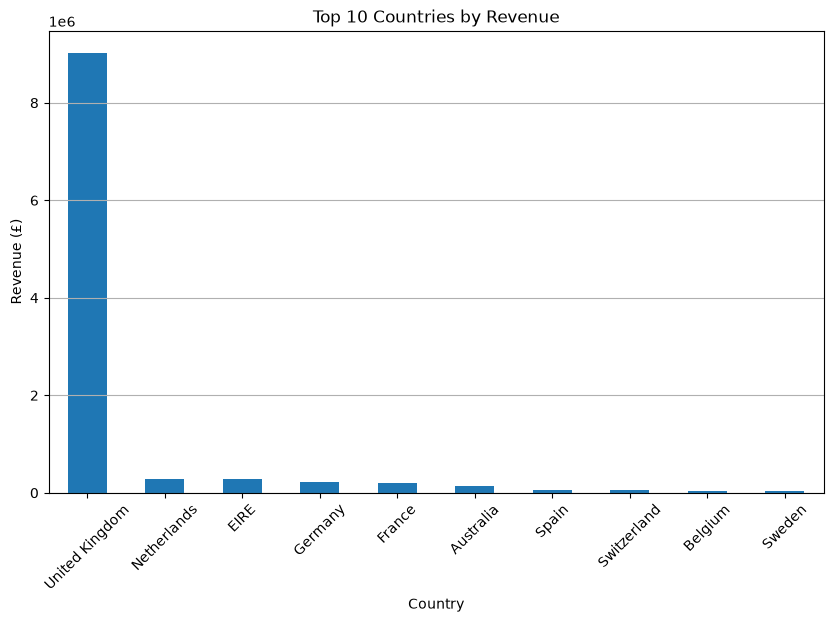

In [104]:
top_10_countries = country_revenue.head(10)

top_10_countries.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.savefig("../visualizations/top_countries_revenue.png", bbox_inches="tight")
plt.show()

## 9. Customer Analysis

Customer-level analysis is performed to understand purchasing behavior and identify high-value and frequent customers.

The analysis includes:

- Total revenue by customer
- Purchase frequency
- Average order value
- Customer recency
- Customer frequency
- Customer monetary value

In [62]:
customer_revenue = sales_df.groupby("CustomerID")["Revenue"].sum()

In [63]:
customer_revenue = customer_revenue.sort_values(ascending=False)

In [64]:
customer_revenue.head(10)

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194550.79
16446.0    168472.50
14911.0    143825.06
12415.0    124914.53
14156.0    117379.63
17511.0     91062.38
16029.0     81024.84
12346.0     77183.60
Name: Revenue, dtype: float64

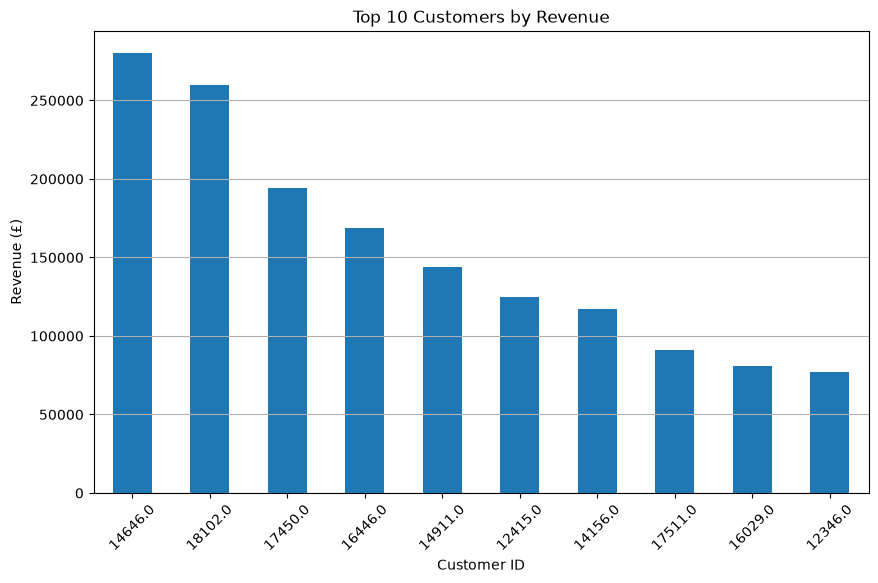

In [105]:
top_10_customers = customer_revenue.head(10)

top_10_customers.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.savefig("../visualizations/top_customers_revenue.png", bbox_inches="tight")
plt.show()

In [66]:
customer_transactions = sales_df.groupby("CustomerID")["InvoiceNo"].nunique()

In [67]:
customer_transactions = customer_transactions.sort_values(ascending=False)

In [68]:
customer_transactions.head(10)

CustomerID
12748.0    209
14911.0    201
17841.0    124
13089.0     97
14606.0     93
15311.0     91
12971.0     86
14646.0     73
16029.0     63
13408.0     62
Name: InvoiceNo, dtype: int64

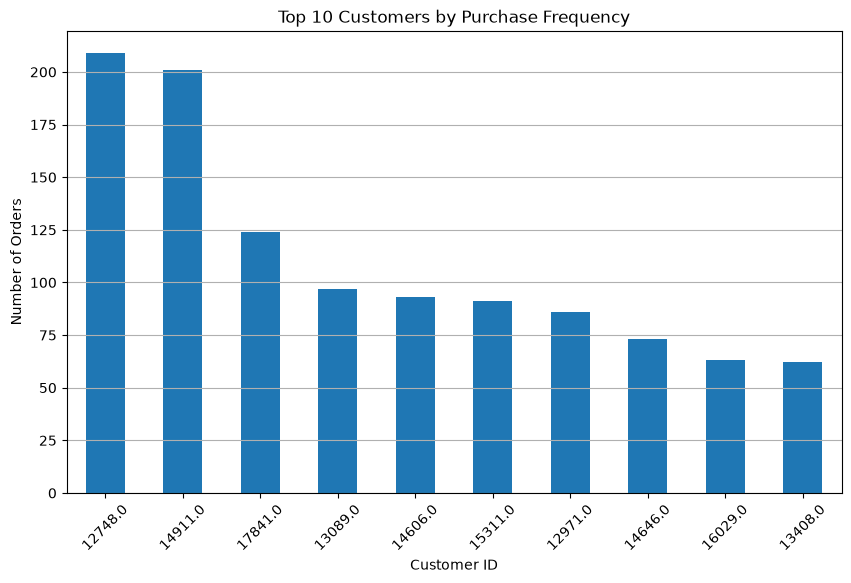

In [106]:
top_10_frequency = customer_transactions.head(10)

top_10_frequency.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Top 10 Customers by Purchase Frequency")
plt.xlabel("Customer ID")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.savefig("../visualizations/top_customers_frequency.png", bbox_inches="tight")
plt.show()

In [70]:
invoice_revenue = sales_df.groupby("InvoiceNo")["Revenue"].sum()

In [71]:
average_order_value = invoice_revenue.mean()
average_order_value

np.float64(534.403033266533)

In [72]:
customer_order_value = (
    sales_df.groupby(["CustomerID", "InvoiceNo"])["Revenue"].sum()
    .groupby("CustomerID")
    .mean()
)

In [73]:
customer_order_value = customer_order_value.sort_values(ascending=False)

In [74]:
customer_order_value.head(10)

CustomerID
16446.0    84236.250000
12346.0    77183.600000
15749.0    14844.766667
15098.0    13305.500000
12357.0     6207.670000
12415.0     5948.310952
12590.0     4932.130000
12688.0     4873.810000
12752.0     4366.780000
18102.0     4327.621667
Name: Revenue, dtype: float64

In [75]:
latest_date = sales_df["InvoiceDate"].max()
latest_date

Timestamp('2011-12-09 12:50:00')

In [76]:
customer_last_purchase = sales_df.groupby("CustomerID")["InvoiceDate"].max()

In [77]:
customer_recency = (latest_date - customer_last_purchase).dt.days

In [78]:
customer_recency.sort_values().head(10)

CustomerID
17364.0    0
12433.0    0
13599.0    0
13536.0    0
16933.0    0
17581.0    0
15898.0    0
16892.0    0
17644.0    0
15910.0    0
Name: InvoiceDate, dtype: int64

## 10. RFM Analysis

RFM analysis is used to understand customer value based on three dimensions:

- **Recency** – How recently a customer made a purchase.
- **Frequency** – How often a customer made a purchase.
- **Monetary** – How much revenue a customer generated.

Customers are assigned scores for each dimension and combined into an overall RFM score.

In [79]:
rfm = pd.DataFrame({
    "Recency": customer_recency,
    "Frequency": customer_transactions,
    "Monetary": customer_revenue
})

In [80]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,325,1,77183.60
12347.0,1,7,4310.00
12348.0,74,4,1797.24
12349.0,18,1,1757.55
12350.0,309,1,334.40


In [81]:
rfm.shape

(4338, 3)

In [82]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    5,
    labels=[5, 4, 3, 2, 1]
)

In [83]:
rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
)

In [84]:
rfm["M_Score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
)

In [85]:
rfm.head(10)

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
CustomerID,,,,,,
12346.0,325,1,77183.60,1,1,5
12347.0,1,7,4310.00,5,5,5
12348.0,74,4,1797.24,2,4,4
12349.0,18,1,1757.55,4,1,4
12350.0,309,1,334.40,1,1,2
12352.0,35,8,2506.04,3,5,5
12353.0,203,1,89.00,1,1,1
12354.0,231,1,1079.40,1,1,4
12355.0,213,1,459.40,1,1,2


In [86]:
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(int)
    + rfm["F_Score"].astype(int)
    + rfm["M_Score"].astype(int)
)

In [87]:
rfm.sort_values("RFM_Score", ascending=False).head(10)

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,,,,
18283.0,3,16,2094.88,5,5,5,15
18245.0,6,7,2567.06,5,5,5,15
18241.0,9,17,2073.09,5,5,5,15
18230.0,8,7,2810.20,5,5,5,15
18229.0,11,20,7276.90,5,5,5,15
18225.0,2,12,5509.12,5,5,5,15
18223.0,4,14,6484.54,5,5,5,15
18219.0,2,10,2069.77,5,5,5,15
18210.0,1,6,2621.38,5,5,5,15


In [88]:
def segment_customer(score):
    if score >= 13:
        return "Best Customers"
    elif score >= 10:
        return "Loyal Customers"
    elif score >= 7:
        return "Potential Customers"
    else:
        return "At Risk"

## 11. Customer Segmentation

Customers are grouped into four segments based on their RFM scores:

- **Best Customers** – High-value and highly engaged customers.
- **Loyal Customers** – Customers with strong and consistent purchasing behavior.
- **Potential Customers** – Customers who show potential for increased engagement.
- **At Risk** – Customers with relatively low engagement or longer periods since their last purchase.

These segment definitions are custom thresholds created for this project to demonstrate customer segmentation using RFM analysis.

In [89]:
rfm["Segment"] = rfm["RFM_Score"].apply(segment_customer)

In [90]:
rfm["Segment"].value_counts()

Segment
At Risk                1304
Potential Customers    1092
Loyal Customers        1008
Best Customers          934
Name: count, dtype: int64

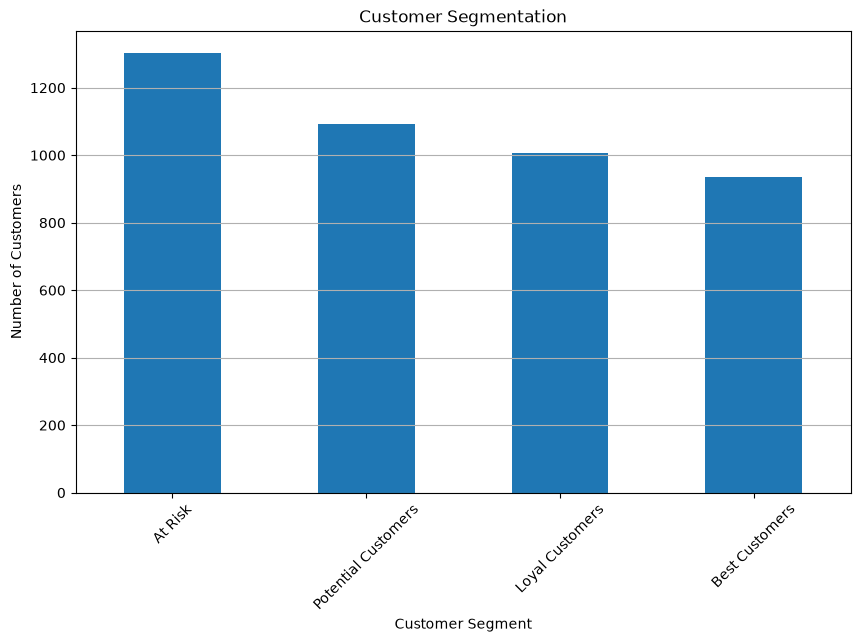

In [107]:
segment_counts = rfm["Segment"].value_counts()

segment_counts.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Customer Segmentation")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.savefig("../visualizations/customer_segments.png", bbox_inches="tight")
plt.show()

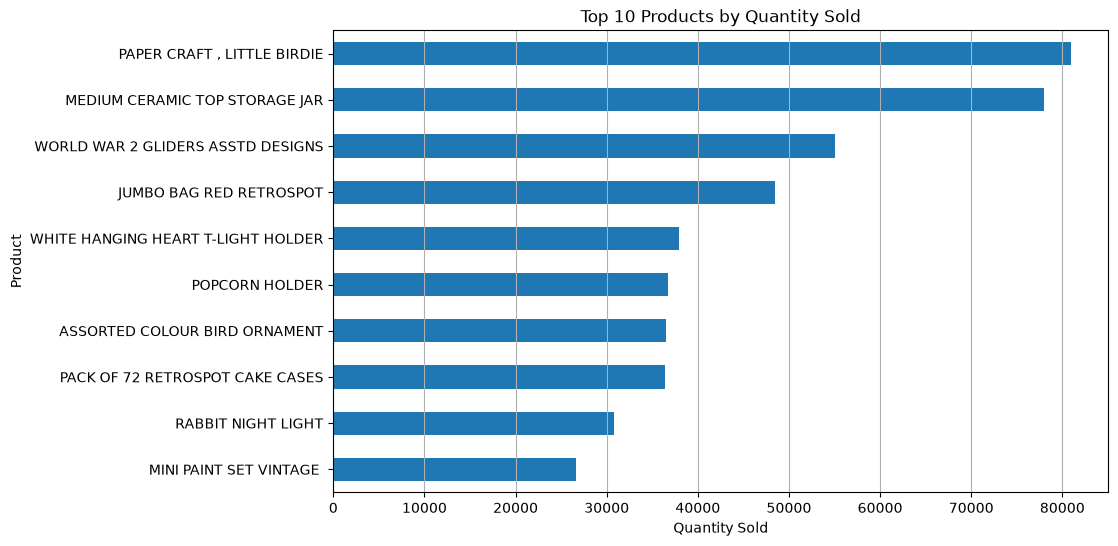

In [103]:
top_10_quantity = product_quantity.head(10)

top_10_quantity.plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")
plt.gca().invert_yaxis()
plt.grid(axis="x")
plt.savefig("../visualizations/top_products_quantity.png", bbox_inches="tight")
plt.show()

In [93]:
exclude_items = [
    "DOTCOM POSTAGE",
    "POSTAGE",
    "Manual"
]

product_sales = sales_df[
    ~sales_df["Description"].isin(exclude_items)
]

In [94]:
actual_product_revenue = (
    product_sales.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

In [95]:
actual_product_revenue.head(10)

Description
REGENCY CAKESTAND 3 TIER              174484.74
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106292.77
PARTY BUNTING                          99504.33
JUMBO BAG RED RETROSPOT                94340.05
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
RABBIT NIGHT LIGHT                     66964.99
PAPER CHAIN KIT 50'S CHRISTMAS         64952.29
ASSORTED COLOUR BIRD ORNAMENT          59094.93
CHILLI LIGHTS                          54117.76
Name: Revenue, dtype: float64

In [96]:
product_avg_price = (
    sales_df.groupby("Description")["UnitPrice"]
    .mean()
    .sort_values(ascending=False)
)

In [97]:
product_avg_price.loc[actual_product_revenue.head(10).index]

Description
REGENCY CAKESTAND 3 TIER              13.976926
PAPER CRAFT , LITTLE BIRDIE            2.080000
WHITE HANGING HEART T-LIGHT HOLDER     3.216948
PARTY BUNTING                          5.794273
JUMBO BAG RED RETROSPOT                2.485459
MEDIUM CERAMIC TOP STORAGE JAR         1.468480
RABBIT NIGHT LIGHT                     2.380502
PAPER CHAIN KIT 50'S CHRISTMAS         3.356833
ASSORTED COLOUR BIRD ORNAMENT          1.722290
CHILLI LIGHTS                          6.789522
Name: UnitPrice, dtype: float64

In [98]:
top_products = actual_product_revenue.head(10)

top_product_share = (top_products / actual_product_revenue.sum()) * 100

top_product_share

Description
REGENCY CAKESTAND 3 TIER              1.693333
PAPER CRAFT , LITTLE BIRDIE           1.634957
WHITE HANGING HEART T-LIGHT HOLDER    1.031546
PARTY BUNTING                         0.965666
JUMBO BAG RED RETROSPOT               0.915548
MEDIUM CERAMIC TOP STORAGE JAR        0.792888
RABBIT NIGHT LIGHT                    0.649879
PAPER CHAIN KIT 50'S CHRISTMAS        0.630346
ASSORTED COLOUR BIRD ORNAMENT         0.573502
CHILLI LIGHTS                         0.525200
Name: Revenue, dtype: float64

In [99]:
country_aov = (
    sales_df.groupby(["Country", "InvoiceNo"])["Revenue"]
    .sum()
    .groupby("Country")
    .mean()
    .sort_values(ascending=False)
)

country_aov.head(10)

Country
Singapore      3039.898571
Netherlands    3036.663191
Australia      2430.198421
Japan          1969.282632
Lebanon        1693.880000
Hong Kong      1426.527273
Brazil         1143.600000
Sweden         1066.064722
Switzerland    1057.220370
Denmark        1053.074444
Name: Revenue, dtype: float64

# Business Insights

## 1. Overall Sales Performance

- The cleaned dataset contains positive completed-sales-style transactions from December 2010 to December 2011.
- Total revenue generated was approximately £10.67 million.
- November 2011 recorded the highest monthly revenue at approximately £1.51 million.

## 2. Product Performance

- REGENCY CAKESTAND 3 TIER was the highest-revenue actual product, generating approximately £174,485.
- PAPER CRAFT, LITTLE BIRDIE generated approximately £168,470 despite having a relatively low average selling price of £2.08.
- This shows that both product price and sales volume influence revenue performance.

## 3. Customer Insights

- 4,338 customers with identifiable CustomerIDs were analyzed.
- Customer purchase behavior varies significantly in terms of recency, frequency, and monetary value.
- RFM analysis was used to divide customers into Best Customers, Loyal Customers, Potential Customers, and At Risk segments.

## 4. Geographic Insights

- The United Kingdom generated approximately 84.6% of total revenue and was the dominant market.
- Singapore and the Netherlands had the highest average order values among the countries analyzed, at approximately £3,040.
- Smaller international markets can have high average order values even when their total revenue is relatively low.

## 5. Business Recommendations

- Focus retention campaigns on Best Customers and Loyal Customers.
- Develop re-engagement campaigns for At Risk customers.
- Promote high-performing products through targeted campaigns and bundles.
- Investigate high-AOV international markets for potential expansion.
- Monitor monthly sales trends to identify seasonal demand patterns.